# ============================================================
# Deep Learning for Fake News Detection
# ============================================================

This notebook implements multiple Deep Learning models for fake news detection using the preprocessed WELFake dataset.

Models implemented:

• CNN
• LSTM
• GRU
• BiLSTM

The objective is to compare the performance of different Deep Learning architectures using identical data preprocessing, training strategy, and evaluation metrics.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import time
import random
import pickle
import warnings

import time
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

Set Random Seed

In [3]:
# ============================================================
# Set Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=" * 70)
print("Random Seed Initialized")
print("=" * 70)

print(f"Seed : {SEED}")

Random Seed Initialized
Seed : 42


Device Configuration

In [4]:
# ============================================================
# Device Configuration
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("Device Configuration")
print("=" * 70)

print(f"Device : {device}")

if torch.cuda.is_available():

    print(f"GPU : {torch.cuda.get_device_name(0)}")

Device Configuration
Device : cuda
GPU : Tesla T4


Load Preprocessed Dataset

In [5]:
# ============================================================
# Load Preprocessed Dataset
# ============================================================

DATA_PATH = "/content/drive/MyDrive/Fake detection/data/preprocessed_welfake.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)

print(f"Shape : {df.shape}")

display(df.head())

Dataset Loaded Successfully
Shape : (63673, 2)


,clean_text,label
0,law enforcement high alert follow threat cop w...,1
1,post vote hillary already,1
2,unbelievable obama attorney general say charlo...,1
3,bobby jindal raise hindu us story christian co...,0
4,satan russia unvelis image terrify new supernu...,1


Train, Validation & Test Split

In [6]:
# ============================================================
# Train, Validation & Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# Features and Labels
X = df["clean_text"]
y = df["label"]

# ------------------------------------------------------------
# Step 1 : Train + Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=SEED,

    stratify=y

)

# ------------------------------------------------------------
# Step 2 : Train + Validation Split
# ------------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(

    X_train,
    y_train,

    test_size=0.10,

    random_state=SEED,

    stratify=y_train

)

print("=" * 70)
print("Dataset Split Summary")
print("=" * 70)

print(f"Training Samples   : {len(X_train)}")
print(f"Validation Samples : {len(X_val)}")
print(f"Testing Samples    : {len(X_test)}")

print("\nTraining Labels")
print(y_train.value_counts())

print("\nValidation Labels")
print(y_val.value_counts())

print("\nTesting Labels")
print(y_test.value_counts())

Dataset Split Summary
Training Samples   : 45844
Validation Samples : 5094
Testing Samples    : 12735

Training Labels
label
0    25048
1    20796
Name: count, dtype: int64

Validation Labels
label
0    2783
1    2311
Name: count, dtype: int64

Testing Labels
label
0    6958
1    5777
Name: count, dtype: int64


In [7]:
print(X_train.isna().sum())
print(df["clean_text"].isna().sum())

39
50


In [8]:
X_train = X_train.fillna("")
X_val = X_val.fillna("")
X_test = X_test.fillna("")

In [9]:
text_lengths = X_train.str.split().str.len()

print(text_lengths.describe())

print("\n90th Percentile :", np.percentile(text_lengths, 90))
print("95th Percentile :", np.percentile(text_lengths, 95))
print("99th Percentile :", np.percentile(text_lengths, 99))

count    45844.000000
mean       310.989770
std        326.235442
min          0.000000
25%        140.000000
50%        237.000000
75%        389.000000
max      12006.000000
Name: clean_text, dtype: float64

90th Percentile : 624.0
95th Percentile : 783.0
99th Percentile : 1459.0


In [10]:
print("=" * 70)
print("Empty Text Analysis")
print("=" * 70)

empty_text = (X_train.str.strip() == "").sum()

print(f"Empty texts in training set : {empty_text}")

Empty Text Analysis
Empty texts in training set : 39


In [11]:
# ============================================================
# Remove Empty Text Samples
# ============================================================

def remove_empty_texts(X, y):

    mask = X.str.strip() != ""

    return X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)


X_train, y_train = remove_empty_texts(X_train, y_train)
X_val, y_val = remove_empty_texts(X_val, y_val)
X_test, y_test = remove_empty_texts(X_test, y_test)

print("=" * 70)
print("Empty Text Removal")
print("=" * 70)

print(f"Training Samples   : {len(X_train)}")
print(f"Validation Samples : {len(X_val)}")
print(f"Testing Samples    : {len(X_test)}")

Empty Text Removal
Training Samples   : 45805
Validation Samples : 5091
Testing Samples    : 12727


Text Processing Configuration

In [12]:
# ============================================================
# Text Processing Configuration
# ============================================================

VOCAB_SIZE = 30000

MAX_LENGTH = 512

OOV_TOKEN = "<OOV>"

PADDING_TYPE = "post"

TRUNCATING_TYPE = "post"

print("=" * 70)
print("Text Processing Configuration")
print("=" * 70)

print(f"Vocabulary Size : {VOCAB_SIZE:,}")
print(f"Maximum Length  : {MAX_LENGTH}")
print(f"OOV Token       : {OOV_TOKEN}")
print(f"Padding Type    : {PADDING_TYPE}")
print(f"Truncating Type : {TRUNCATING_TYPE}")

Text Processing Configuration
Vocabulary Size : 30,000
Maximum Length  : 512
OOV Token       : <OOV>
Padding Type    : post
Truncating Type : post


Tokenizer

In [13]:
# ============================================================
# Build Tokenizer
# ============================================================

tokenizer = Tokenizer(

    num_words=VOCAB_SIZE,

    oov_token=OOV_TOKEN

)

print("Fitting tokenizer on training data...")

tokenizer.fit_on_texts(X_train)

print("\nTokenizer Created Successfully!")

print(f"\nTotal Unique Words : {len(tokenizer.word_index):,}")

print(f"Vocabulary Size Used : {VOCAB_SIZE:,}")

Fitting tokenizer on training data...

Tokenizer Created Successfully!

Total Unique Words : 151,385
Vocabulary Size Used : 30,000


In [14]:
print(f"Words Ignored : {len(tokenizer.word_index) - VOCAB_SIZE:,}")

Words Ignored : 121,385


In [15]:
# ============================================================
# Verify Tokenizer
# ============================================================

print("=" * 70)
print("Sample Word Index")
print("=" * 70)

for word in list(tokenizer.word_index.keys())[:20]:

    print(f"{word:<20} -> {tokenizer.word_index[word]}")

Sample Word Index
<OOV>                -> 1
say                  -> 2
trump                -> 3
u                    -> 4
state                -> 5
would                -> 6
president            -> 7
one                  -> 8
people               -> 9
year                 -> 10
mr                   -> 11
make                 -> 12
new                  -> 13
time                 -> 14
clinton              -> 15
go                   -> 16
take                 -> 17
also                 -> 18
get                  -> 19
republican           -> 20


In [16]:
print(X_train.iloc[0])
print(X_train.iloc[1])
print(X_train.iloc[2])

nota conceptual para la presidencia de rusia reuni n del consejo de seguridad de de octubre de nota conceptual para la presidencia de rusia red voltaire nueva york ee uu de octubre de fran ai english cooperaci n entre las naciones unidas las organizaciones regionales subregionales en el mantenimiento de la paz la seguridad internacionales organizaci n del tratado de seguridad colectiva organizaci n de cooperaci n de shangh comunidad de estados independientes como actividad central durante su presidencia en el consejo de seguridad la federaci n de rusia tiene previsto celebrar un debate el de octubre de sobre el tema cooperaci n entre las naciones unidas las organizaciones regionales subregionales en el mantenimiento de la paz la seguridad internacionales organizaci n del tratado de seguridad colectiva organizaci n de cooperaci n de shangh comunidad de estados independientes el car cter mundial de los desaf o amenazas actuales la elaboraci n de los enfoques colectivos necesarios para ab

Convert Text to Integer Sequences

In [17]:
# ============================================================
# Text to Integer Sequences
# ============================================================

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

X_test_seq = tokenizer.texts_to_sequences(X_test)

print("=" * 70)
print("Sequence Generation Completed")
print("=" * 70)

print(f"Training Sequences   : {len(X_train_seq)}")
print(f"Validation Sequences : {len(X_val_seq)}")
print(f"Testing Sequences    : {len(X_test_seq)}")

print("\nSample Sequence")

print(X_train_seq[0][:30])



Sequence Generation Completed
Training Sequences   : 45805
Validation Sequences : 5091
Testing Sequences    : 12727

Sample Sequence
[1, 16902, 4201, 643, 1, 343, 18333, 1, 274, 2749, 21856, 343, 15486, 343, 343, 27424, 343, 1, 16902, 4201, 643, 1, 343, 18333, 999, 14957, 15648, 91, 17411, 22897]


Padding

In [18]:
# ============================================================
# Sequence Padding
# ============================================================

X_train_pad = pad_sequences(

    X_train_seq,

    maxlen=MAX_LENGTH,

    padding=PADDING_TYPE,

    truncating=TRUNCATING_TYPE

)

X_val_pad = pad_sequences(

    X_val_seq,

    maxlen=MAX_LENGTH,

    padding=PADDING_TYPE,

    truncating=TRUNCATING_TYPE

)

X_test_pad = pad_sequences(

    X_test_seq,

    maxlen=MAX_LENGTH,

    padding=PADDING_TYPE,

    truncating=TRUNCATING_TYPE

)

print("=" * 70)
print("Sequence Padding Completed")
print("=" * 70)

print(f"Training Shape   : {X_train_pad.shape}")
print(f"Validation Shape : {X_val_pad.shape}")
print(f"Testing Shape    : {X_test_pad.shape}")

Sequence Padding Completed
Training Shape   : (45805, 512)
Validation Shape : (5091, 512)
Testing Shape    : (12727, 512)


In [19]:

# ============================================================
# Project Directories
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fake detection"

DATA_DIR = os.path.join(BASE_DIR, "data")

MODELS_DIR = os.path.join(BASE_DIR, "models")

ML_MODEL_DIR = os.path.join(MODELS_DIR, "ml")

DL_MODEL_DIR = os.path.join(MODELS_DIR, "dl")

RESULTS_DIR = os.path.join(BASE_DIR, "results")

PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

TOKENIZER_PATH = os.path.join(MODELS_DIR, "tokenizer.pkl")

os.makedirs(ML_MODEL_DIR, exist_ok=True)
os.makedirs(DL_MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

Save Tokenizer

In [20]:
# ============================================================
# Save Tokenizer
# ============================================================


os.makedirs(ML_MODEL_DIR, exist_ok=True)
os.makedirs(DL_MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TOKENIZER_PATH = os.path.join(MODELS_DIR, "tokenizer.pkl")

with open(TOKENIZER_PATH, "wb") as file:

    pickle.dump(tokenizer, file)

print("=" * 70)
print("Tokenizer Saved Successfully")
print("=" * 70)

print(TOKENIZER_PATH)

Tokenizer Saved Successfully
/content/drive/MyDrive/Fake detection/models/tokenizer.pkl


In [21]:
sample_text = X_train.iloc[0]

print("Original Text:")
print(sample_text[:300])

print("\nSequence:")
print(X_train_seq[0][:30])

print("\nPadded Sequence:")
print(X_train_pad[0][:30])

Original Text:
nota conceptual para la presidencia de rusia reuni n del consejo de seguridad de de octubre de nota conceptual para la presidencia de rusia red voltaire nueva york ee uu de octubre de fran ai english cooperaci n entre las naciones unidas las organizaciones regionales subregionales en el mantenimient

Sequence:
[1, 16902, 4201, 643, 1, 343, 18333, 1, 274, 2749, 21856, 343, 15486, 343, 343, 27424, 343, 1, 16902, 4201, 643, 1, 343, 18333, 999, 14957, 15648, 91, 17411, 22897]

Padded Sequence:
[    1 16902  4201   643     1   343 18333     1   274  2749 21856   343
 15486   343   343 27424   343     1 16902  4201   643     1   343 18333
   999 14957 15648    91 17411 22897]


# ============================================================
# PyTorch Dataset and DataLoader
# ============================================================

The padded NumPy arrays are converted into PyTorch tensors and wrapped using TensorDataset.

DataLoader is then used to efficiently load mini-batches during training and evaluation of all Deep Learning models.

Convert NumPy Arrays to PyTorch Tensors

In [22]:
# ============================================================
# Convert NumPy Arrays to PyTorch Tensors
# ============================================================

X_train_tensor = torch.tensor(
    X_train_pad,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val_pad,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_pad,
    dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

print("=" * 70)
print("Tensor Conversion Completed")
print("=" * 70)

print(f"Training Features   : {X_train_tensor.shape}")
print(f"Training Labels     : {y_train_tensor.shape}")

print()

print(f"Validation Features : {X_val_tensor.shape}")
print(f"Validation Labels   : {y_val_tensor.shape}")

print()

print(f"Testing Features    : {X_test_tensor.shape}")
print(f"Testing Labels      : {y_test_tensor.shape}")

Tensor Conversion Completed
Training Features   : torch.Size([45805, 512])
Training Labels     : torch.Size([45805])

Validation Features : torch.Size([5091, 512])
Validation Labels   : torch.Size([5091])

Testing Features    : torch.Size([12727, 512])
Testing Labels      : torch.Size([12727])


Create TensorDataset

In [23]:
# ============================================================
# Create TensorDataset
# ============================================================

from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

validation_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("=" * 70)
print("TensorDataset Created Successfully")
print("=" * 70)

print(f"Training Samples   : {len(train_dataset)}")
print(f"Validation Samples : {len(validation_dataset)}")
print(f"Testing Samples    : {len(test_dataset)}")

TensorDataset Created Successfully
Training Samples   : 45805
Validation Samples : 5091
Testing Samples    : 12727


DataLoader Configuration

In [24]:
# ============================================================
# DataLoader Configuration
# ============================================================

BATCH_SIZE = 64

NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()

print("=" * 70)
print("DataLoader Configuration")
print("=" * 70)

print(f"Batch Size  : {BATCH_SIZE}")
print(f"Workers     : {NUM_WORKERS}")
print(f"Pin Memory  : {PIN_MEMORY}")

DataLoader Configuration
Batch Size  : 64
Workers     : 2
Pin Memory  : True


Create DataLoaders

In [25]:
# ============================================================
# Create DataLoaders
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

print("=" * 70)
print("DataLoaders Created Successfully")
print("=" * 70)

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(validation_loader)}")
print(f"Testing Batches    : {len(test_loader)}")

DataLoaders Created Successfully
Training Batches   : 716
Validation Batches : 80
Testing Batches    : 199


Verify DataLoader

In [26]:
# ============================================================
# Verify DataLoader
# ============================================================

features, labels = next(iter(train_loader))

print("=" * 70)
print("Mini Batch Verification")
print("=" * 70)

print(f"Features Shape : {features.shape}")

print(f"Labels Shape   : {labels.shape}")

print("\nFeature Data Type :", features.dtype)

print("Label Data Type   :", labels.dtype)

Mini Batch Verification
Features Shape : torch.Size([64, 512])
Labels Shape   : torch.Size([64])

Feature Data Type : torch.int64
Label Data Type   : torch.float32


# ============================================================
# Deep Learning Configuration
# ============================================================

This section defines the common hyperparameters and training configuration that will be shared across all Deep Learning models.

Using a common configuration ensures a fair comparison between CNN, LSTM, GRU and BiLSTM models while keeping the implementation modular and reproducible.

CELL 1

In [27]:
# ============================================================
# Deep Learning Configuration
# ============================================================

EMBEDDING_DIM = 128

HIDDEN_DIM = 128

DROPOUT = 0.5

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

EPOCHS = 15

BATCH_SIZE = 64

PATIENCE = 3

print("=" * 70)
print("Deep Learning Configuration")
print("=" * 70)

print(f"Embedding Dimension : {EMBEDDING_DIM}")
print(f"Hidden Dimension    : {HIDDEN_DIM}")
print(f"Dropout             : {DROPOUT}")
print(f"Learning Rate       : {LEARNING_RATE}")
print(f"Weight Decay        : {WEIGHT_DECAY}")
print(f"Epochs              : {EPOCHS}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Early Stop Patience : {PATIENCE}")

Deep Learning Configuration
Embedding Dimension : 128
Hidden Dimension    : 128
Dropout             : 0.5
Learning Rate       : 0.001
Weight Decay        : 0.0001
Epochs              : 15
Batch Size          : 64
Early Stop Patience : 3


# ============================================================
# Convolutional Neural Network (CNN)
# ============================================================

A Convolutional Neural Network (CNN) is a Deep Learning architecture that learns local patterns from text using convolutional filters.

Instead of processing the entire sentence at once, CNN scans small groups of neighboring words (n-grams) to identify meaningful patterns such as phrases, expressions and contextual cues that help distinguish fake news from real news.

The architecture implemented in this notebook consists of:

• Embedding Layer
• 1D Convolution Layer
• ReLU Activation
• Global Max Pooling
• Dropout
• Fully Connected Output Layer

Cell 1 — CNN Configuration

In [28]:
# ============================================================
# CNN Configuration
# ============================================================

NUM_FILTERS = 128

KERNEL_SIZE = 5

print("=" * 70)
print("CNN Configuration")
print("=" * 70)

print(f"Number of Filters : {NUM_FILTERS}")
print(f"Kernel Size       : {KERNEL_SIZE}")

CNN Configuration
Number of Filters : 128
Kernel Size       : 5


📌 Cell 2 — CNN Architecture

In [29]:
# ============================================================
# CNN Model
# ============================================================

class CNNClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_filters,
        kernel_size,
        dropout
    ):

        super().__init__()

        # Word Embedding
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )

        # Convolution Layer
        self.conv = nn.Conv1d(
            in_channels=embedding_dim,
            out_channels=num_filters,
            kernel_size=kernel_size
        )

        # Activation
        self.relu = nn.ReLU()

        # Global Max Pooling
        self.pool = nn.AdaptiveMaxPool1d(1)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Output Layer
        self.fc = nn.Linear(
            num_filters,
            1
        )

    def forward(self, x):

        # ------------------------------------------
        # Embedding
        # Shape:
        # (batch, seq_len)
        # ->
        # (batch, seq_len, embedding_dim)
        # ------------------------------------------

        x = self.embedding(x)

        # ------------------------------------------
        # Conv1D expects:
        # (batch, channels, seq_len)
        # ------------------------------------------

        x = x.permute(0, 2, 1)

        # Convolution

        x = self.conv(x)

        # Activation

        x = self.relu(x)

        # Global Max Pool

        x = self.pool(x)

        # Remove last dimension

        x = x.squeeze(2)

        # Dropout

        x = self.dropout(x)

        # Output

        x = self.fc(x)

        return x.squeeze(1)

LSTM Architecture

# ============================================================
# Long Short-Term Memory (LSTM)
# ============================================================

Long Short-Term Memory (LSTM) is a recurrent neural network designed to learn long-range dependencies in sequential data.

Unlike CNN, which captures local patterns, LSTM processes text sequentially and maintains a memory of previous words, allowing it to understand contextual relationships throughout the sentence.

The architecture implemented in this notebook consists of:

• Embedding Layer
• LSTM Layer
• Dropout
• Fully Connected Output Layer

LSTM Configuration

In [30]:
# ============================================================
# LSTM Configuration
# ============================================================

LSTM_HIDDEN_DIM = 128

LSTM_NUM_LAYERS = 1

print("=" * 70)
print("LSTM Configuration")
print("=" * 70)

print(f"Hidden Dimension : {LSTM_HIDDEN_DIM}")
print(f"Number of Layers : {LSTM_NUM_LAYERS}")

LSTM Configuration
Hidden Dimension : 128
Number of Layers : 1


📌 LSTM Architecture

In [31]:
# ============================================================
# LSTM Model
# ============================================================

class LSTMClassifier(nn.Module):

    def __init__(

        self,

        vocab_size,

        embedding_dim,

        hidden_dim,

        num_layers,

        dropout

    ):

        super().__init__()

        # Word Embedding
        self.embedding = nn.Embedding(

            num_embeddings=vocab_size,

            embedding_dim=embedding_dim

        )

        # LSTM Layer
        self.lstm = nn.LSTM(

            input_size=embedding_dim,

            hidden_size=hidden_dim,

            num_layers=num_layers,

            batch_first=True

        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Output Layer
        self.fc = nn.Linear(

            hidden_dim,

            1

        )

    def forward(self, x):

        # ------------------------------------------
        # Embedding
        # (batch, seq_len)
        # ->
        # (batch, seq_len, embedding_dim)
        # ------------------------------------------

        x = self.embedding(x)

        # ------------------------------------------
        # LSTM
        # ------------------------------------------

        output, (hidden, cell) = self.lstm(x)

        # Last Hidden State
        hidden = hidden[-1]

        # Dropout
        hidden = self.dropout(hidden)

        # Output Layer
        output = self.fc(hidden)

        return output.squeeze(1)

# ============================================================
# Gated Recurrent Unit (GRU)
# ============================================================

The Gated Recurrent Unit (GRU) is a simplified recurrent neural network that captures sequential dependencies while using fewer parameters than LSTM.

GRU combines memory and gating mechanisms into a simpler architecture, making it computationally efficient while maintaining competitive performance on many Natural Language Processing tasks.

The architecture implemented in this notebook consists of:

• Embedding Layer
• GRU Layer
• Dropout
• Fully Connected Output Layer

In [32]:
# ============================================================
# GRU Configuration
# ============================================================

GRU_HIDDEN_DIM = 128

GRU_NUM_LAYERS = 1

print("=" * 70)
print("GRU Configuration")
print("=" * 70)

print(f"Hidden Dimension : {GRU_HIDDEN_DIM}")
print(f"Number of Layers : {GRU_NUM_LAYERS}")

GRU Configuration
Hidden Dimension : 128
Number of Layers : 1


In [33]:
# ============================================================
# GRU Model
# ============================================================

class GRUClassifier(nn.Module):

    def __init__(

        self,

        vocab_size,

        embedding_dim,

        hidden_dim,

        num_layers,

        dropout

    ):

        super().__init__()

        # Word Embedding
        self.embedding = nn.Embedding(

            num_embeddings=vocab_size,

            embedding_dim=embedding_dim

        )

        # GRU Layer
        self.gru = nn.GRU(

            input_size=embedding_dim,

            hidden_size=hidden_dim,

            num_layers=num_layers,

            batch_first=True

        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Output Layer
        self.fc = nn.Linear(

            hidden_dim,

            1

        )

    def forward(self, x):

        # ------------------------------------------
        # Embedding
        # ------------------------------------------

        x = self.embedding(x)

        # ------------------------------------------
        # GRU
        # ------------------------------------------

        output, hidden = self.gru(x)

        # Last Hidden State
        hidden = hidden[-1]

        # Dropout
        hidden = self.dropout(hidden)

        # Output Layer
        output = self.fc(hidden)

        return output.squeeze(1)

# ============================================================
# Bidirectional Long Short-Term Memory (BiLSTM)
# ============================================================

Bidirectional Long Short-Term Memory (BiLSTM) extends the standard LSTM by processing the input sequence in both forward and backward directions.

Instead of learning context only from past words, BiLSTM captures information from both previous and future words, enabling richer contextual understanding for text classification.

The architecture implemented in this notebook consists of:

• Embedding Layer
• Bidirectional LSTM Layer
• Dropout
• Fully Connected Output Layer

In [34]:
# ============================================================
# BiLSTM Configuration
# ============================================================

BILSTM_HIDDEN_DIM = 128

BILSTM_NUM_LAYERS = 1

print("=" * 70)
print("BiLSTM Configuration")
print("=" * 70)

print(f"Hidden Dimension : {BILSTM_HIDDEN_DIM}")
print(f"Number of Layers : {BILSTM_NUM_LAYERS}")

BiLSTM Configuration
Hidden Dimension : 128
Number of Layers : 1


In [35]:
# ============================================================
# BiLSTM Model
# ============================================================

class BiLSTMClassifier(nn.Module):

    def __init__(

        self,

        vocab_size,

        embedding_dim,

        hidden_dim,

        num_layers,

        dropout

    ):

        super().__init__()

        # Word Embedding
        self.embedding = nn.Embedding(

            num_embeddings=vocab_size,

            embedding_dim=embedding_dim

        )

        # Bidirectional LSTM
        self.lstm = nn.LSTM(

            input_size=embedding_dim,

            hidden_size=hidden_dim,

            num_layers=num_layers,

            batch_first=True,

            bidirectional=True

        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Output Layer
        self.fc = nn.Linear(

            hidden_dim * 2,

            1

        )

    def forward(self, x):

        # ------------------------------------------
        # Embedding
        # ------------------------------------------

        x = self.embedding(x)

        # ------------------------------------------
        # BiLSTM
        # ------------------------------------------

        output, (hidden, cell) = self.lstm(x)

        # Concatenate Forward + Backward Hidden States
        hidden = torch.cat(

            (hidden[-2], hidden[-1]),

            dim=1

        )

        # Dropout
        hidden = self.dropout(hidden)

        # Output Layer
        output = self.fc(hidden)

        return output.squeeze(1)

# ============================================================
# Model Registry
# ============================================================

All Deep Learning architectures are registered in a common dictionary along with their initialization parameters.

This design eliminates duplicate code and enables any model to be instantiated dynamically during training.

The registry also provides a clean and scalable framework for adding new architectures in the future.

Model Registry

In [36]:
# ============================================================
# Model Registry
# ============================================================

MODEL_REGISTRY = {

    "CNN": {

        "class": CNNClassifier,

        "params": {

            "vocab_size": VOCAB_SIZE,

            "embedding_dim": EMBEDDING_DIM,

            "num_filters": NUM_FILTERS,

            "kernel_size": KERNEL_SIZE,

            "dropout": DROPOUT

        }

    },

    "LSTM": {

        "class": LSTMClassifier,

        "params": {

            "vocab_size": VOCAB_SIZE,

            "embedding_dim": EMBEDDING_DIM,

            "hidden_dim": LSTM_HIDDEN_DIM,

            "num_layers": LSTM_NUM_LAYERS,

            "dropout": DROPOUT

        }

    },

    "GRU": {

        "class": GRUClassifier,

        "params": {

            "vocab_size": VOCAB_SIZE,

            "embedding_dim": EMBEDDING_DIM,

            "hidden_dim": GRU_HIDDEN_DIM,

            "num_layers": GRU_NUM_LAYERS,

            "dropout": DROPOUT

        }

    },

    "BiLSTM": {

        "class": BiLSTMClassifier,

        "params": {

            "vocab_size": VOCAB_SIZE,

            "embedding_dim": EMBEDDING_DIM,

            "hidden_dim": BILSTM_HIDDEN_DIM,

            "num_layers": BILSTM_NUM_LAYERS,

            "dropout": DROPOUT

        }

    }

}

print("=" * 70)
print("Registered Models")
print("=" * 70)

for model_name in MODEL_REGISTRY:

    print(model_name)

Registered Models
CNN
LSTM
GRU
BiLSTM


Verify Model Creation

In [37]:
# ============================================================
# Verify Model Registry
# ============================================================

for model_name, model_info in MODEL_REGISTRY.items():

    model = model_info["class"](

        **model_info["params"]

    )

    print(f"{model_name:<10} : Successfully Initialized")

CNN        : Successfully Initialized
LSTM       : Successfully Initialized
GRU        : Successfully Initialized
BiLSTM     : Successfully Initialized


# ============================================================
# Training Configuration
# ============================================================

This section defines the common training components that will be shared across all Deep Learning models.

A common loss function, optimizer, learning rate scheduler and early stopping strategy ensure a fair comparison between all architectures while keeping the training pipeline modular and reusable.

1 - Loss Function

In [38]:
# ============================================================
# Loss Function
# ============================================================

criterion = nn.BCEWithLogitsLoss()

print("=" * 70)
print("Loss Function")
print("=" * 70)

print(type(criterion).__name__)

Loss Function
BCEWithLogitsLoss


2 — Optimizer Factory

In [39]:
# ============================================================
# Optimizer Factory
# ============================================================

def create_optimizer(model):

    return torch.optim.AdamW(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=WEIGHT_DECAY

    )

3 — Scheduler Factory

In [40]:
# ============================================================
# Learning Rate Scheduler Factory
# ============================================================

def create_scheduler(optimizer):

    return torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=2

    )

4 — Early Stopping Class

In [41]:
# ============================================================
# Early Stopping
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=PATIENCE,

        min_delta=0

    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = float("inf")

        self.counter = 0

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True

5 — Verify Training Configuration

In [42]:
# ============================================================
# Verify Training Configuration
# ============================================================

print("=" * 70)
print("Training Configuration")
print("=" * 70)

print(f"Loss Function : {type(criterion).__name__}")

print(f"Optimizer     : AdamW")

print(f"Scheduler     : ReduceLROnPlateau")

print(f"Early Stop    : {PATIENCE} Epochs")

Training Configuration
Loss Function : BCEWithLogitsLoss
Optimizer     : AdamW
Scheduler     : ReduceLROnPlateau
Early Stop    : 3 Epochs


# ============================================================
# Universal Training Function
# ============================================================

A common training pipeline is implemented for all Deep Learning models.

The function performs:

• Forward Pass
• Loss Computation
• Backpropagation
• Optimizer Update
• Validation
• Learning Rate Scheduling
• Early Stopping
• Best Model Saving

This eliminates duplicate code and enables any architecture to be trained using the same pipeline.

1 — Universal Training Function

In [43]:
# ============================================================
# Universal Training Function
# ============================================================

def train_model(

    model,

    train_loader,

    validation_loader,

    criterion,

    optimizer,

    scheduler,

    model_name,

    device

):

    start_time = time.time()

    history = {

        "train_loss": [],

        "val_loss": [],

        "train_accuracy": [],

        "val_accuracy": []

    }

    early_stopping = EarlyStopping()

    best_val_loss = float("inf")

    best_epoch = 0

    best_model_path = os.path.join(
        DL_MODEL_DIR,
        f"{model_name.lower()}_best.pth"
    )

    for epoch in range(EPOCHS):

        # ===================================================
        # Training
        # ===================================================

        model.train()

        running_loss = 0.0

        correct = 0

        total = 0

        progress_bar = tqdm(
          train_loader,
          total=len(train_loader),
          desc=f"{model_name} Epoch {epoch+1}/{EPOCHS}"
      )

        for features, labels in progress_bar:

            features = features.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(features)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            predictions = (torch.sigmoid(outputs) >= 0.5).float()

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

        train_loss = running_loss / len(train_loader)

        train_accuracy = correct / total

        # ===================================================
        # Validation
        # ===================================================

        model.eval()

        running_loss = 0.0

        correct = 0

        total = 0

        with torch.no_grad():

            for features, labels in tqdm(

                validation_loader,

                desc=f"{model_name} | Validation",

                leave=False

            ):

                features = features.to(device)

                labels = labels.to(device)

                outputs = model(features)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                predictions = (torch.sigmoid(outputs) >= 0.5).float()

                correct += (predictions == labels).sum().item()

                total += labels.size(0)

        val_loss = running_loss / len(validation_loader)

        val_accuracy = correct / total

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)

        history["val_loss"].append(val_loss)

        history["train_accuracy"].append(train_accuracy)

        history["val_accuracy"].append(val_accuracy)

        # ===================================================
        # Save Best Model
        # ===================================================

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_epoch = epoch + 1

            torch.save(

                model.state_dict(),

                best_model_path

            )

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2%} | "
            f"Val Acc: {val_accuracy:.2%} | "
            f"LR: {current_lr:.6f}"
        )

        early_stopping(val_loss)

        if early_stopping.early_stop:

            print("\nEarly Stopping Triggered.")

            break

    training_time = time.time() - start_time

    return {

        "history": history,

        "best_epoch": best_epoch,

        "best_val_loss": best_val_loss,

        "training_time": training_time,

        "best_model_path": best_model_path

    }

# ============================================================
# Universal Evaluation Function
# ============================================================

This function evaluates any trained Deep Learning model on the test dataset.

It computes:

• Test Loss
• Accuracy
• Precision
• Recall
• F1-Score
• ROC-AUC Score
• Confusion Matrix

The same evaluation pipeline is shared across all Deep Learning architectures.

1 — Universal Evaluation Function

In [44]:
# ============================================================
# Universal Evaluation Function
# ============================================================

def evaluate_model(

    model,

    test_loader,

    criterion,

    device

):

    model.eval()

    running_loss = 0.0

    predictions = []

    probabilities = []

    true_labels = []

    with torch.no_grad():

        for features, labels in tqdm(

            test_loader,

            desc="Testing",

            leave=False

        ):

            features = features.to(device)

            labels = labels.to(device)

            outputs = model(features)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).float()

            predictions.extend(preds.cpu().numpy().tolist())

            probabilities.extend(probs.cpu().numpy().tolist())

            true_labels.extend(labels.cpu().numpy().tolist())

    test_loss = running_loss / len(test_loader)

    accuracy = accuracy_score(

        true_labels,

        predictions

    )

    precision = precision_score(

        true_labels,

        predictions,

        zero_division=0

    )

    recall = recall_score(

        true_labels,

        predictions,

        zero_division=0

    )

    f1 = f1_score(

        true_labels,

        predictions,

        zero_division=0

    )

    roc_auc = roc_auc_score(

        true_labels,

        probabilities

    )

    cm = confusion_matrix(

        true_labels,

        predictions

    )

    report = classification_report(

        true_labels,

        predictions,

        zero_division=0,

        output_dict=True

    )

    return {

        "Test Loss": test_loss,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc,

        "Confusion Matrix": cm,

        "Classification Report": report,

        "True Labels": true_labels,

        "Probabilities": probabilities

    }

2 — Train Selected Models

In [45]:
# ============================================================
# Train Selected Models
# ============================================================

def train_selected_models(

    selected_models

):

    results = {}

    histories = {}

    for model_name in selected_models:

        print("\n" + "=" * 70)

        print(f"Training {model_name}")

        print("=" * 70)

        model_info = MODEL_REGISTRY[model_name]

        model = model_info["class"](

            **model_info["params"]

        ).to(device)

        optimizer = create_optimizer(model)

        scheduler = create_scheduler(optimizer)

        # ---------------------------------------------------
        # Train Model
        # ---------------------------------------------------

        training_info = train_model(

            model=model,

            train_loader=train_loader,

            validation_loader=validation_loader,

            criterion=criterion,

            optimizer=optimizer,

            scheduler=scheduler,

            model_name=model_name,

            device=device

        )

        # ---------------------------------------------------
        # Load Best Model
        # ---------------------------------------------------

        model.load_state_dict(

            torch.load(

                training_info["best_model_path"],

                map_location=device

            )

        )

        # ---------------------------------------------------
        # Evaluate Model
        # ---------------------------------------------------

        evaluation = evaluate_model(

            model,

            test_loader,

            criterion,

            device

        )

        histories[model_name] = training_info

        results[model_name] = evaluation

        print("\n" + "-" * 70)

        print(f"{model_name} Training Completed")

        print(f"Best Epoch      : {training_info['best_epoch']}")

        print(f"Best Val Loss   : {training_info['best_val_loss']:.4f}")

        print(f"Training Time   : {training_info['training_time']:.2f} sec")

        print("-" * 70)

    print("\n" + "=" * 70)

    print("All Selected Models Trained Successfully")

    print("=" * 70)

    return histories, results

# ============================================================
# Model Selection
# ============================================================

Choose the models that you want to train.

You can train a single model, multiple models, or all available architectures without modifying the training pipeline.

3 — Model Selection

In [46]:
# ============================================================
# Model Selection
# ============================================================

SELECTED_MODELS = [

    "CNN",

    "LSTM",

    "GRU",

    "BiLSTM"

]

4 — Start Training

In [47]:
# ============================================================
# Train Selected Models
# ============================================================

print("=" * 70)
print("Starting Deep Learning Training Pipeline")
print("=" * 70)

print(f"Selected Models : {', '.join(SELECTED_MODELS)}")
print(f"Device          : {device}")
print(f"Epochs          : {EPOCHS}")
print(f"Batch Size      : {BATCH_SIZE}")
print("=" * 70)

histories, results = train_selected_models(

    SELECTED_MODELS

)

print("\n" + "=" * 70)
print("Deep Learning Training Completed Successfully")
print("=" * 70)

Starting Deep Learning Training Pipeline
Selected Models : CNN, LSTM, GRU, BiLSTM
Device          : cuda
Epochs          : 15
Batch Size      : 64

Training CNN


CNN Epoch 1/15:   0%|          | 0/716 [00:00<?, ?it/s]

CNN | Validation:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 0.2761 | Val Loss: 0.1436 | Train Acc: 87.53% | Val Acc: 94.52% | LR: 0.001000


CNN Epoch 2/15:   0%|          | 0/716 [00:00<?, ?it/s]

...

BiLSTM Epoch 5/15:   0%|          | 0/716 [00:00<?, ?it/s]

BiLSTM | Validation:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 05/15 | Train Loss: 0.0356 | Val Loss: 0.1544 | Train Acc: 98.90% | Val Acc: 95.27% | LR: 0.000500

Early Stopping Triggered.


Testing:   0%|          | 0/199 [00:00<?, ?it/s]


----------------------------------------------------------------------
BiLSTM Training Completed
Best Epoch      : 2
Best Val Loss   : 0.1353
Training Time   : 114.01 sec
----------------------------------------------------------------------

All Selected Models Trained Successfully

Deep Learning Training Completed Successfully


In [58]:
# =============================================================
# Results Summary
# ===========================================================

results_df = pd.DataFrame(results).T

display(results_df)

,Test Loss,Accuracy,Precision,Recall,F1 Score,ROC AUC,Confusion Matrix,Classification Report,True Labels,Probabilities
CNN,0.08783,0.965035,0.960235,0.962732,0.961482,0.995293,"[[6728, 230], [215, 5554]]","{'0.0': {'precision': 0.9690335589802679, 'rec...","[1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, ...","[0.9955933690071106, 1.8243054000777192e-07, 0..."
LSTM,0.131673,0.955606,0.947694,0.954758,0.951213,0.991798,"[[6654, 304], [261, 5508]]","{'0.0': {'precision': 0.9622559652928416, 'rec...","[1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, ...","[0.9834571480751038, 0.0010345436166971922, 0...."
GRU,0.085149,0.968885,0.96407,0.967412,0.965738,0.995781,"[[6750, 208], [188, 5581]]","{'0.0': {'precision': 0.9729028538483713, 'rec...","[1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, ...","[0.9818909764289856, 0.0017243720358237624, 0...."
BiLSTM,0.146074,0.94437,0.918195,0.963079,0.940102,0.98511,"[[6463, 495], [213, 5556]]","{'0.0': {'precision': 0.9680946674655483, 'rec...","[1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, ...","[0.9919677376747131, 0.0002622670726850629, 0...."


# ============================================================
# Deep Learning Model Comparison
# ============================================================

Comparison of all Deep Learning architectures on the test dataset using multiple evaluation metrics.

In [49]:
# ============================================================
# Deep Learning Results Summary
# ============================================================

summary_data = []

for model_name, metrics in results.items():

    summary_data.append({

        "Model": model_name,

        "Accuracy": round(metrics["Accuracy"] * 100, 2),

        "Precision": round(metrics["Precision"] * 100, 2),

        "Recall": round(metrics["Recall"] * 100, 2),

        "F1 Score": round(metrics["F1 Score"] * 100, 2),

        "ROC AUC": round(metrics["ROC AUC"] * 100, 2),

        "Test Loss": round(metrics["Test Loss"], 4),

        "Best Epoch": histories[model_name]["best_epoch"],

        "Training Time (sec)": round(histories[model_name]["training_time"],2)

    })

results_df = pd.DataFrame(summary_data)

results_df.sort_values(

    by="Accuracy",

    ascending=False,

    inplace=True

)

results_df.reset_index(

    drop=True,

    inplace=True

)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Test Loss,Best Epoch,Training Time (sec)
0,GRU,96.89,96.41,96.74,96.57,99.58,0.0851,4,63.34
1,CNN,96.50,96.02,96.27,96.15,99.53,0.0878,5,56.36
2,LSTM,95.56,94.77,95.48,95.12,99.18,0.1317,8,134.08
3,BiLSTM,94.44,91.82,96.31,94.01,98.51,0.1461,2,114.01


Save results in CSV

In [50]:
results_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "deep_learning_results.csv"
    ),
    index=False
)

print("Results Saved Successfully.")

Results Saved Successfully.


# ============================================================
# Training Curves
# ============================================================

The following plots show the training and validation performance of all Deep Learning models across epochs.

These learning curves help analyze convergence, overfitting, and generalization.

1 — Loss Curves

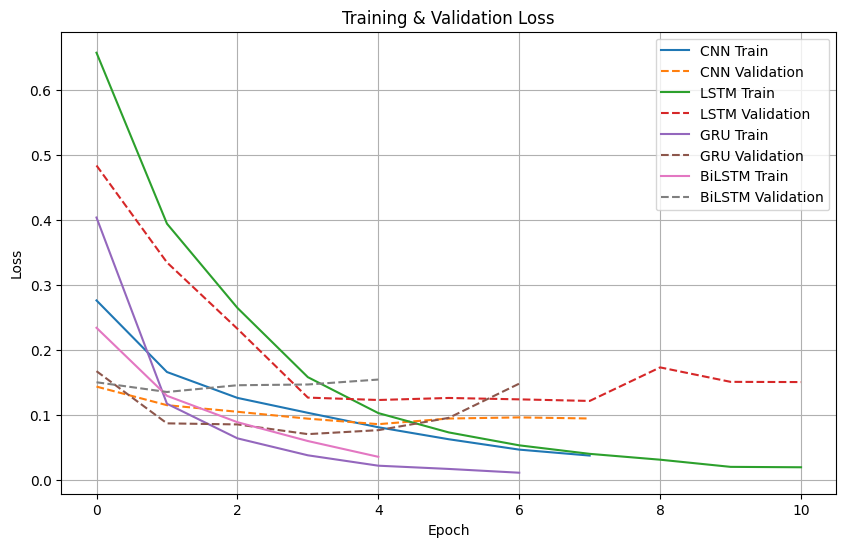

In [51]:
# ============================================================
# Training & Validation Loss
# ============================================================

plt.figure(figsize=(10, 6))

for model_name, info in histories.items():

    history = info["history"]

    plt.plot(
        history["train_loss"],
        label=f"{model_name} Train"
    )

    plt.plot(
        history["val_loss"],
        linestyle="--",
        label=f"{model_name} Validation"
    )

plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(PLOTS_DIR, "training_validation_loss.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

2 — Accuracy Curves

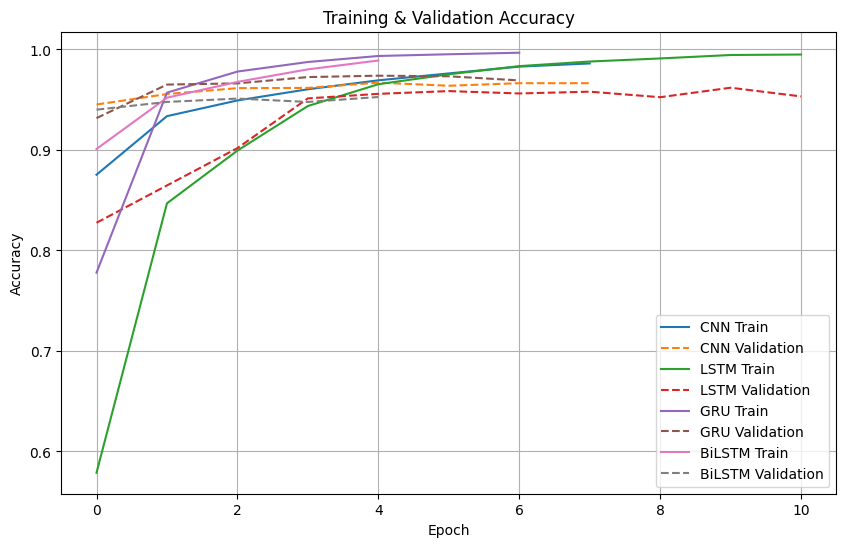

In [52]:
# ============================================================
# Training & Validation Accuracy
# ============================================================

plt.figure(figsize=(10, 6))

for model_name, info in histories.items():

    history = info["history"]

    plt.plot(
        history["train_accuracy"],
        label=f"{model_name} Train"
    )

    plt.plot(
        history["val_accuracy"],
        linestyle="--",
        label=f"{model_name} Validation"
    )

plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(PLOTS_DIR, "training_validation_accuracy.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Confusion Matrix
# ============================================================

The confusion matrix summarizes the classification performance of each Deep Learning model on the test dataset.

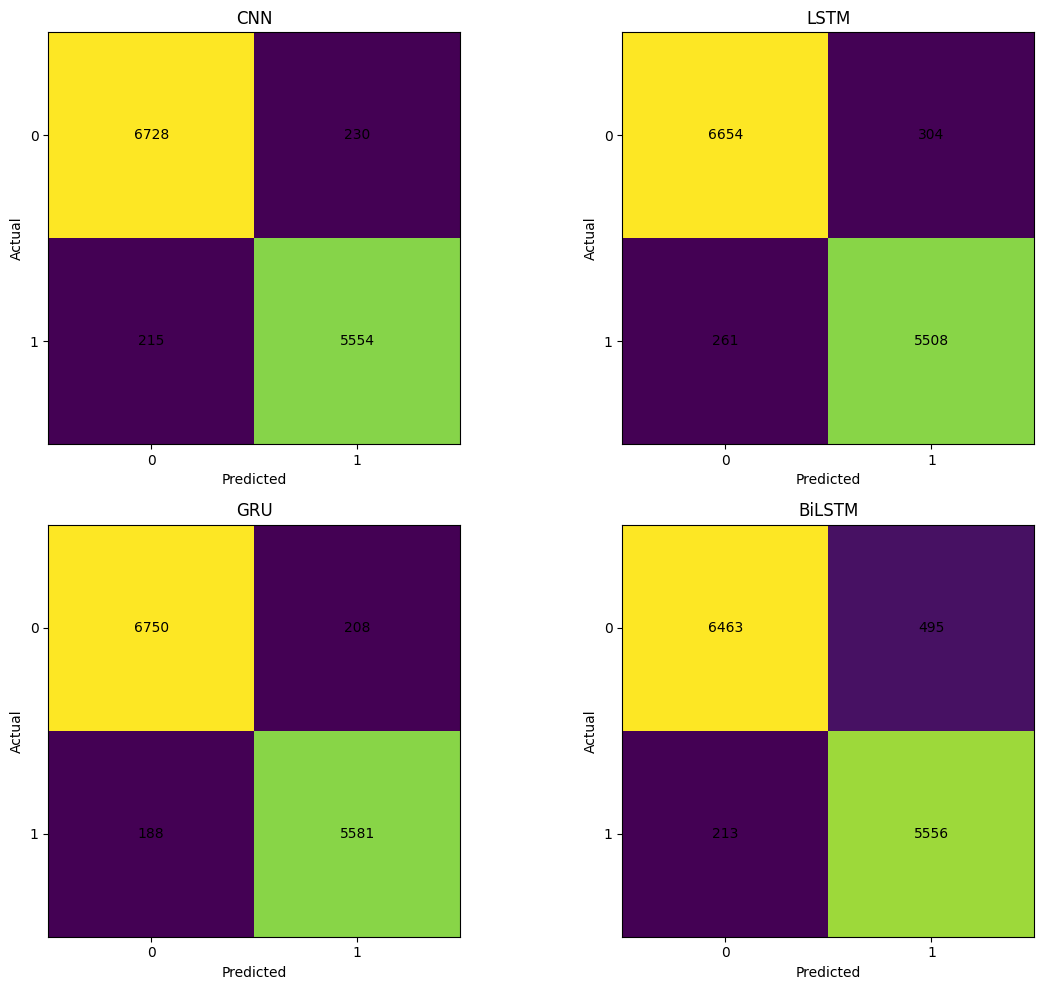

In [53]:
# ============================================================
# Confusion Matrices
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.ravel()

for idx, (model_name, metrics) in enumerate(results.items()):

    cm = metrics["Confusion Matrix"]

    ax = axes[idx]

    ax.imshow(cm)

    ax.set_title(model_name)

    ax.set_xlabel("Predicted")

    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])

    ax.set_yticks([0, 1])

    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "confusion_matrices.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Receiver Operating Characteristic (ROC) Curve
# ============================================================

The ROC Curve illustrates the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR).

A higher Area Under the Curve (AUC) indicates better discriminative performance.

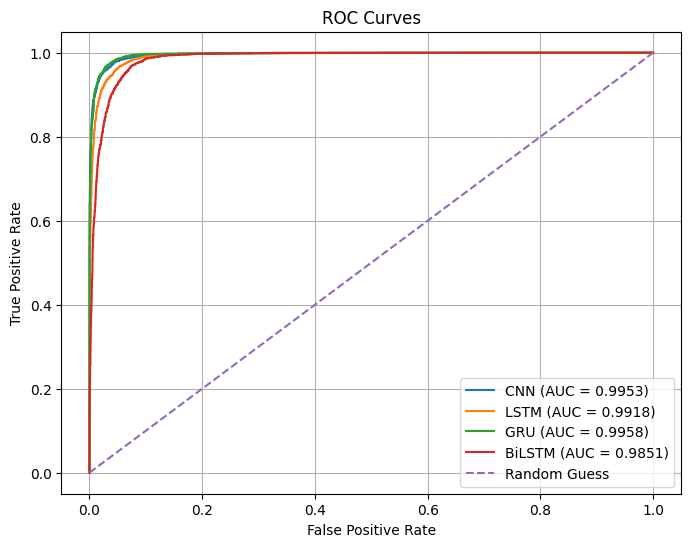

In [54]:
# ============================================================
# ROC Curves
# ============================================================

from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for model_name, metrics in results.items():

    fpr, tpr, _ = roc_curve(
        metrics["True Labels"],
        metrics["Probabilities"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {metrics['ROC AUC']:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(PLOTS_DIR, "roc_curves.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Deep Learning Summary
# ============================================================

Four Deep Learning architectures (CNN, LSTM, GRU, and BiLSTM) were implemented and evaluated on the WELFake dataset.

The models were trained using a unified PyTorch training pipeline with AdamW optimization, learning rate scheduling, dropout regularization, and early stopping to improve generalization and reduce overfitting.

Among all evaluated architectures, the GRU model achieved the best overall performance with:

- Test Accuracy: 96.89%
- Precision: 96.41%
- Recall: 96.74%
- F1 Score: 96.57%
- ROC-AUC: 99.58%

Therefore, the GRU model is selected as the best-performing Deep Learning model and will be used for comparison with Transformer-based models in the next phase of the project.